<a href="https://colab.research.google.com/github/sauravk21/cv_tutorial/blob/main/yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[INFO] loading YOLO from disk...
[INFO] YOLO took 1.474665 seconds
version https://git-lfs.github.com/spec/v1: 0.9988


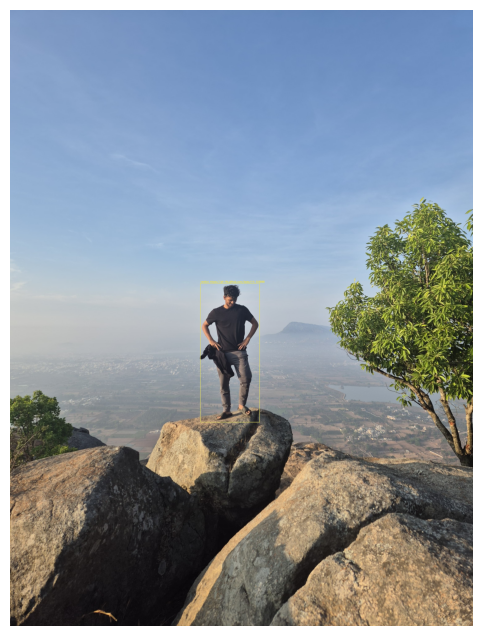

version https://git-lfs.github.com/spec/v1: 0.9988


In [13]:
import numpy as np
import time
import cv2
import os
import matplotlib.pyplot as plt

# ==========================
# FILE PATHS
# ==========================
IMAGE_PATH = "/content/WhatsApp Image 2025-04-05 at 11.13.08 AM.jpeg"
CONFIDENCE = 0.5
NMS_THRESHOLD = 0.3

# load the COCO class labels
labelsPath = "/content/coco.names"
LABELS = open(labelsPath).read().strip().split("\n")

# initialize colors
np.random.seed(42)
COLORS = np.random.randint(
    0, 255,
    size=(len(LABELS), 3),
    dtype="uint8"
)

# YOLO config and weights
weightsPath = "/content/yolov3.weights"
configPath = "/content/yolov3.cfg"

# load YOLO
print("[INFO] loading YOLO from disk...")
net = cv2.dnn.readNetFromDarknet(configPath, weightsPath)

# load image
image = cv2.imread(IMAGE_PATH)

if image is None:
    raise ValueError(f"Could not read image: {IMAGE_PATH}")

(H, W) = image.shape[:2]

# get output layers
ln = net.getLayerNames()
ln = [ln[i - 1] for i in net.getUnconnectedOutLayers().flatten()]

# create blob
blob = cv2.dnn.blobFromImage(
    image,
    1 / 255.0,
    (416, 416),
    swapRB=True,
    crop=False
)

net.setInput(blob)

start = time.time()
layerOutputs = net.forward(ln)
end = time.time()

print(f"[INFO] YOLO took {end - start:.6f} seconds")

boxes = []
confidences = []
classIDs = []

# process detections
for output in layerOutputs:
    for detection in output:
        scores = detection[5:]
        classID = np.argmax(scores)
        confidence = scores[classID]

        if confidence > CONFIDENCE:

            box = detection[0:4] * np.array([W, H, W, H])
            (centerX, centerY, width, height) = box.astype("int")

            x = int(centerX - width / 2)
            y = int(centerY - height / 2)

            boxes.append([x, y, int(width), int(height)])
            confidences.append(float(confidence))
            classIDs.append(classID)

# Non-Maximum Suppression
idxs = cv2.dnn.NMSBoxes(
    boxes,
    confidences,
    CONFIDENCE,
    NMS_THRESHOLD
)

# draw boxes
if len(idxs) > 0:
    for i in idxs.flatten():

        x, y = boxes[i][0], boxes[i][1]
        w, h = boxes[i][2], boxes[i][3]

        color = [int(c) for c in COLORS[classIDs[i]]]

        cv2.rectangle(
            image,
            (x, y),
            (x + w, y + h),
            color,
            2
        )

        text = f"{LABELS[classIDs[i]]}: {confidences[i]:.4f}"
        print(text)
        cv2.putText(
            image,
            text,
            (x, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

print(text)